## Objectives
In this lab we will introduce the R package BGLR (Bayesian General Linear Regression). This package implements many common Bayesian genomic prediction models. In the lab we will analyze 4 different data sets each having different genetic architectures for the traits and different population structures. The goal is to examine the relative impact of model choice, population structure and genetic architecture.

In [1]:
#Loading libraries
req_packages<-c("BGLR", "tidyverse")

for(i in c(1:length(req_packages))){
  if (!require(req_packages[i], character.only = TRUE)){
   install.packages(req_packages[i])
  }
}

Loading required package: BGLR

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘BGLR’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘truncnorm’


Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Reading Genotypic Data
First we are going to read in files containing genotype data for an unrelated population and a population of close relatives as well as a file containing the frequencies for the reference allele. Files associated with the population containing related lines will have an "R" in the file name.

In [2]:
#read genotypic data
#genotypes for unrelated lines in this file
genoDat=read.table("https://raw.githubusercontent.com/Robbins-Lab/PLSCI-4170-7170/refs/heads/main/datasets/data_lab11/centeredGenotypestLab11.csv",sep=",")
#genotypes highly related lines in this file
genoDatR=read.table("https://raw.githubusercontent.com/Robbins-Lab/PLSCI-4170-7170/refs/heads/main/datasets/data_lab11/centeredGenotypestLabR11.csv",sep=",")
#using read.table so need to convert to a matrix
genoDat=as.matrix(genoDat)
genoDatR=as.matrix(genoDatR)
#read in a file with allele frequencies for each marker
#unrelated data
freqs=read.table("https://raw.githubusercontent.com/Robbins-Lab/PLSCI-4170-7170/refs/heads/main/datasets/data_lab11/freqstLab11.csv",sep=",")
#related data
freqsR=read.table("https://raw.githubusercontent.com/Robbins-Lab/PLSCI-4170-7170/refs/heads/main/datasets/data_lab11/freqstLabR11.csv",sep=",")

freqs=as.matrix(freqs)
freqsR=as.matrix(freqsR)

#setting variables with the number of lines and the number of markers
nLines=length(genoDat[,1])
nMarks=length(genoDat[1,])

### Calculate Genomic Relationship matrices

Here we will calculated the Genomic Relationship Matrices. Below I am calculating the genomic relationships for one of the populations, you will need to modify the code to calculate the genomic relationships for the other population.

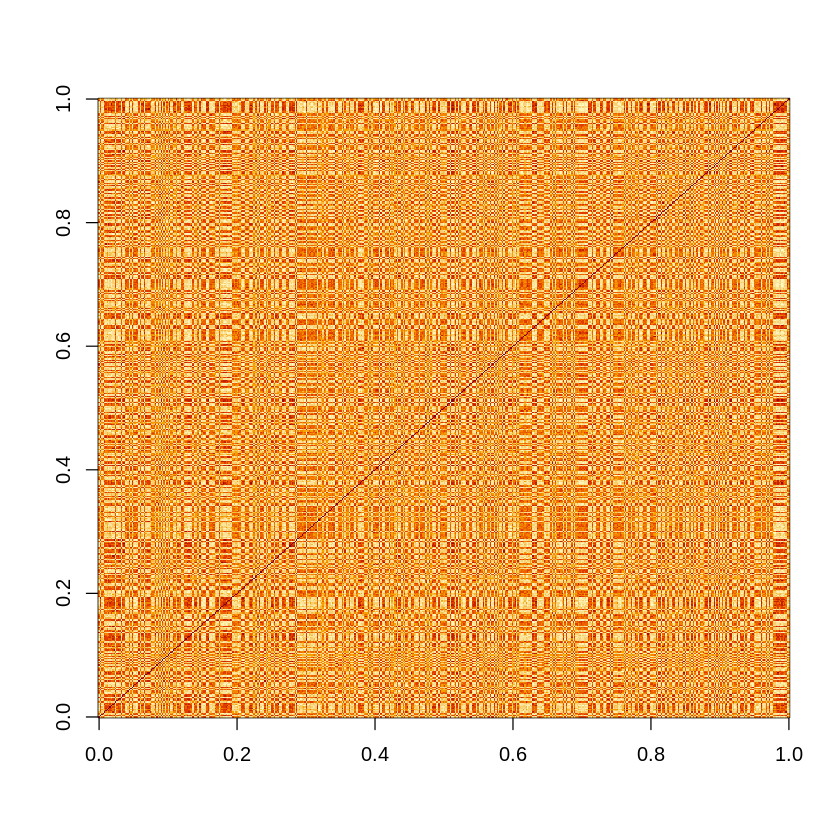

In [3]:
#calculate the G matrix
#calculate scaling factor k
k=0
for(i in c(1:length(freqsR))){
  k=k+2*freqsR[i]*(1-freqsR[i])
}

G=genoDatR%*%t(genoDatR)*(1/k)

image(G)

## Reading in the phenotypic data

Here we read in 4 phenotypic data sets. The phentypes cover 2 traits (one with 30 QTL and the other with 300 QTL). Each of these traits was collected on the unrelated and highly related populations.The code processes one of the phenotypic datafiles for using in BGLR. You will need to modify the code to process all 4 phenotypic datasets.

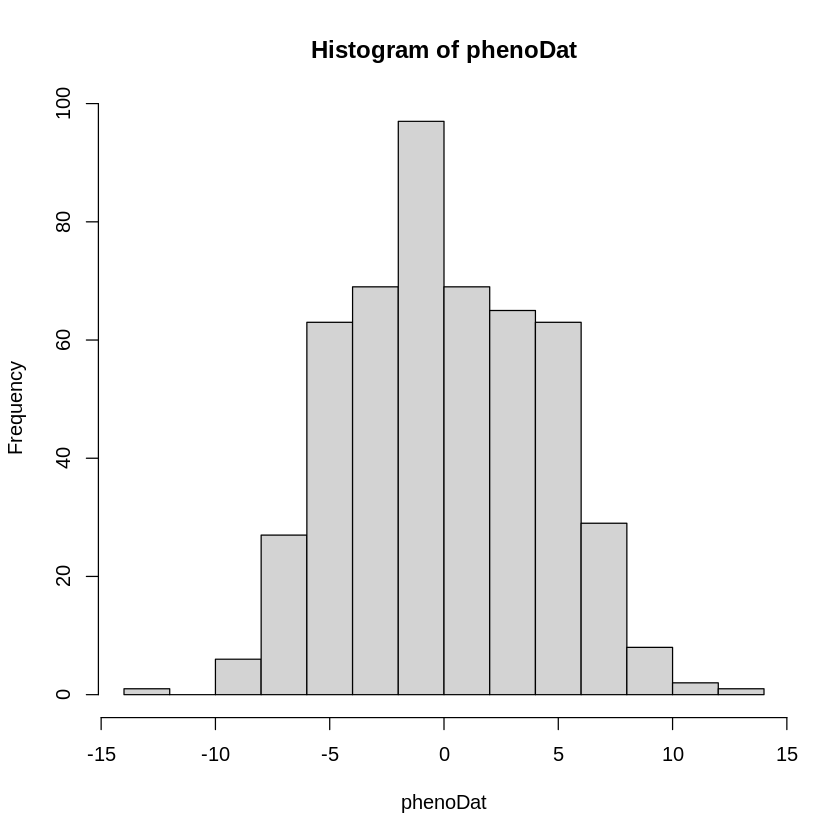

In [4]:
#phenotypes of unrelated lines 300 QTL
phenoDat300=read.table("https://raw.githubusercontent.com/Robbins-Lab/PLSCI-4170-7170/refs/heads/main/datasets/data_lab11/Pheno300Lab11.csv",sep=",")
#phenotypes of unrelated lines 30 QTL
phenoDat30=read.table("https://raw.githubusercontent.com/Robbins-Lab/PLSCI-4170-7170/refs/heads/main/datasets/data_lab11/Pheno30Lab11.csv",sep=",")
#phenotypes of related lines 300 QTL
phenoDatR300=read.table("https://raw.githubusercontent.com/Robbins-Lab/PLSCI-4170-7170/refs/heads/main/datasets/data_lab11/Pheno300RLab11.csv",sep=",")
#phenotypes of related lines 30 QTL
phenoDatR30=read.table("https://raw.githubusercontent.com/Robbins-Lab/PLSCI-4170-7170/refs/heads/main/datasets/data_lab11/Pheno30RLab11.csv",sep=",")

#using read.table so need to convert to a matrix
phenoDat=as.matrix(phenoDatR300)

#some quick summary statistics of phenotypic data
hist(phenoDat)


## Running analysis and cross validation in BGLR
Now that we have genotypic and phenotypic data will will set up an anlysis in BGLR. In the code provided one of the phenotypes on one of the populations is being run using Bayesian Ridge Regression. For the lab assignment you will need to run all phenotypes on both populations using Bayesian Ridge Regression and another model of your choosing. Model accuracy is tested by using 5 fold cross validation. Accuracy is calculated by combining the predictions for masked phenotypes and then correwlating with the measured phenotypes.

            V1
[1,] 0.6811116


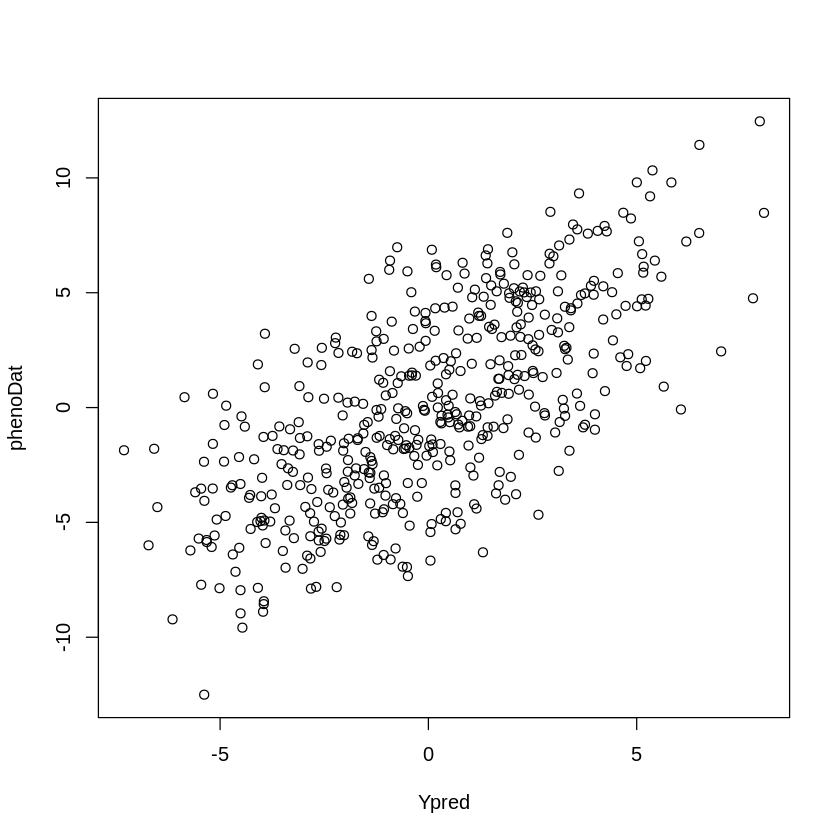

In [5]:
library(BGLR)

#setting fold size - there are 500 lines in the file so hardcoding it as 100 (lazy implementation)
foldSize=100
#variable to track which phenotypes need to be set to NA
currentFoldPos=1
#set up a vector to sore predicted values
Ypred=rep(0,nLines)
#loop for 5 fold cross validation
for(i in c(1:5)){
  #setting up a vector of phenotypes for each fold
  Y=phenoDat
  #mask data for prediction
  Y[currentFoldPos:(currentFoldPos+foldSize-1)]=NA
  #run BGLR
  #BGLR(y, response_type = "gaussian", a=NULL, b=NULL,ETA = NULL, nIter = 1500,
  #    burnIn = 500, thin = 5, saveAt = "", S0 = NULL,
  #    df0 =5, R2 = 0.5, weights = NULL,
  #    verbose = TRUE, rmExistingFiles = TRUE, groups=NULL)
  # Details at https://cran.r-project.org/web/packages/BGLR/BGLR.pdf
  # set up ETA list
  #switch out genodat when modeling different populations
  Model<-list(list(X=genoDatR,model="BRR"))
  #model types appropriate for this marker matrix are "BRR", "BayesA", "BL", "BayesB", "BayesC"
  #If passing in a genomic relationship matrix "RKHS" model type can be used
  #If providing an incidence matrix for fixed effects model type "FIXED"
  result= BGLR(Y, response_type = "gaussian", ETA = Model, nIter = 50000, burnIn = 2000, thin = 100,verbose = FALSE)
  #grab estimates of breeding values from the results list
  Yhat=result$yHat
  Ypred[currentFoldPos:(currentFoldPos+foldSize-1)]=Yhat[currentFoldPos:(currentFoldPos+foldSize-1)]
  #update the variable tracking folds
  currentFoldPos=currentFoldPos+foldSize
}

#summarize prediction performance

acc=cor(Ypred,phenoDat)
print(acc)
plot(Ypred,phenoDat)




## Lab Assignment

1) Run cross validation on all 4 phenotypes and both populations using at least two different models. (4 pts)
2) Compare results and discuss the relative impacts of population structure, trait architecture and model choice. (4 pts)
3) Read in output files containing the MCMC samples from each analysis (for variance components) and do a trace plot (plot sample by iteration) to confirm burn in and good mixing of the chain. (2 pts)
